In [1]:
import matplotlib.pyplot as plt
from tshap.synthetic import DoubleFreqTest
from tshap.tshap import TSHAPExplainer
from tshap.xutil import *

from aeon.datasets import load_classification
from aeon.transformations.collection.convolution_based import MiniRocket
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

### (Synthetic) Time Series Classification

In [2]:
synth_gen = DoubleFreqTest()

X_train,y_train, X_train_true_attribs = synth_gen.generate_classification_data_and_attribs(n_samples = 30, random_seed=0)
X_test, y_test, X_test_true_attribs = synth_gen.generate_classification_data_and_attribs(n_samples = 30, random_seed=1)


In [3]:
# input time series data is a 3D numpy array of shape (n_samples, n_channels, series_length)
# n_channels = 1 for univariate time series or > 1 for multivariate time series
X_train.shape

(30, 1, 200)

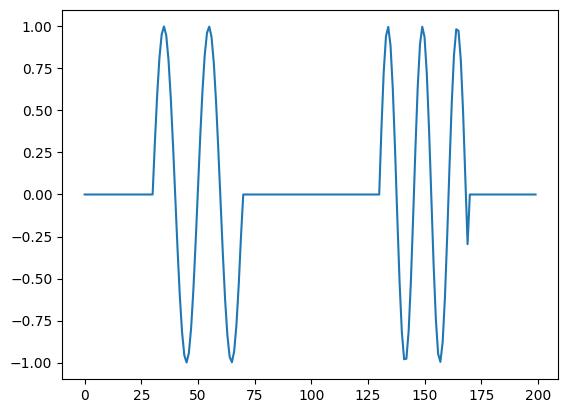

In [4]:
plt.figure
plt.plot(X_train[0,0,:])
plt.show()

In [5]:
# get the hypothetical model
clf = synth_gen.get_classification_model()

In [6]:
y_pred = clf.predict(X_test)
print('Classification Accuracy: ' + str(np.sum(y_test == y_pred) / len(y_test)))

Classification Accuracy: 1.0


In [7]:
tshap_window_attribs,tshap_roi_attribs = TSHAPExplainer().explain(X_test, baselines=X_train, model=clf.decision_function)

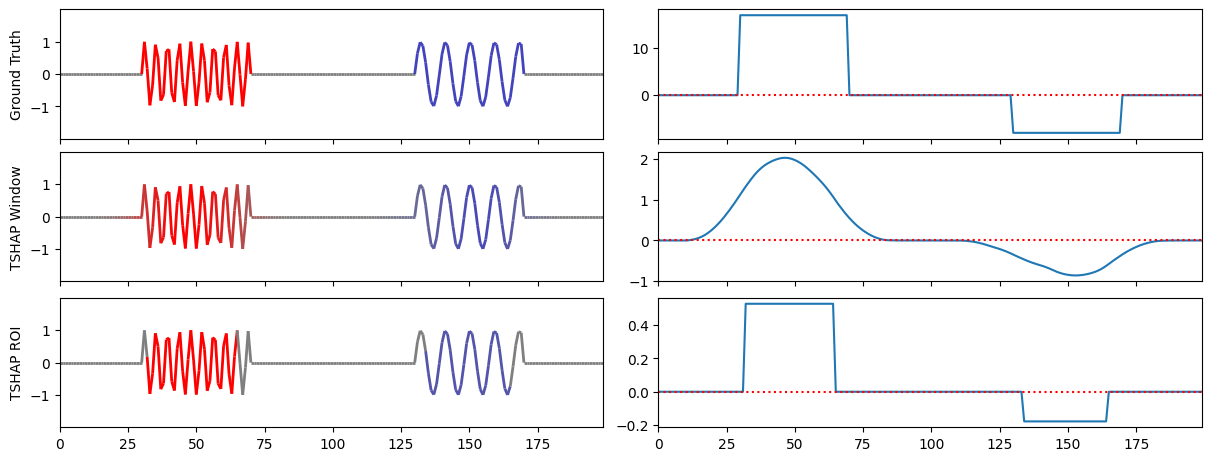

In [8]:
id = 0
sample = X_test[id,0,:]
attribs = [attr[id,0,:] for attr in [X_test_true_attribs, tshap_window_attribs, tshap_roi_attribs]]
plot_saliency_map_and_attributions(sample,attribs, ['Ground Truth', 'TSHAP Window', 'TSHAP ROI'])

### (Synthetic) Time Series Regression

In [34]:
X_train,y_train, X_train_true_attribs = synth_gen.generate_regression_data_and_attribs(n_samples = 30, random_seed=0)
X_test, y_test, X_test_true_attribs = synth_gen.generate_regression_data_and_attribs(n_samples = 30, random_seed=1)

rgr = synth_gen.get_regression_model()


In [35]:
y_pred = rgr.predict(X_test)
mse = np.mean((y_test - y_pred)**2)
print('Regression MSE: ' + str(mse))

Regression MSE: 0.49288896126036436


In [ ]:
# use zero baseline for reference value zero
# see the paper for more details about baseline selection and reference values
tshap_window_attribs,tshap_roi_attribs = TSHAPExplainer().explain(X_test, baselines=np.zeros((1, X_test.shape[1], X_test.shape[2])), model=rgr)

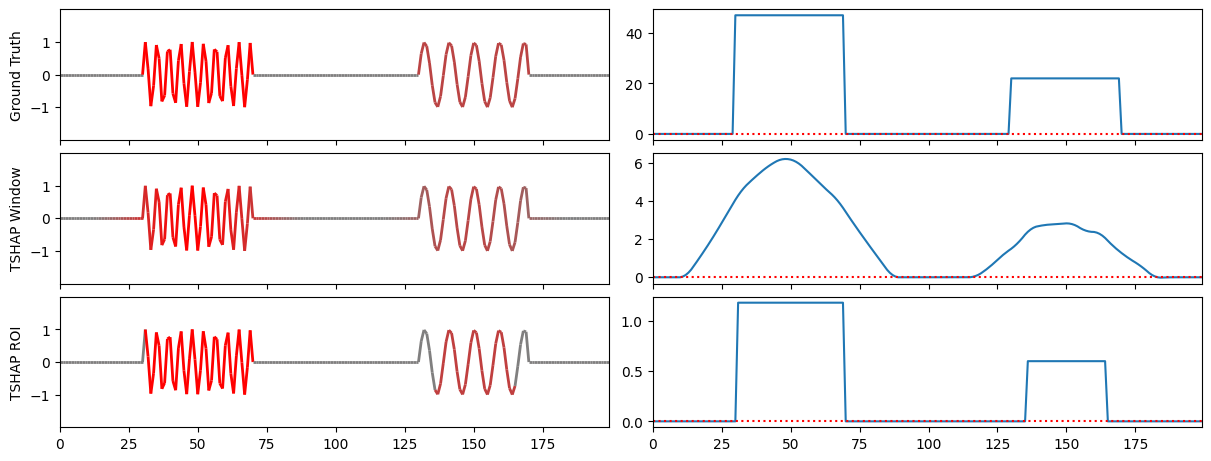

In [40]:
id = 0
sample = X_test[id,0,:]
attribs = [attr[id,0,:] for attr in [X_test_true_attribs, tshap_window_attribs, tshap_roi_attribs]]
plot_saliency_map_and_attributions(sample,attribs, ['Ground Truth', 'TSHAP Window', 'TSHAP ROI'])

### UCR Univariate Time Series

In [10]:
X_train, y_train = load_classification('Coffee',split='train')
X_test, y_test = load_classification('Coffee',split='test')

clf = make_pipeline(
            MiniRocket(random_state=42),
            StandardScaler(with_mean=False),
            LogisticRegression(), # replace the default RidgeCV with LogisticRegression to get the prediction probability
        ).fit(X_train,y_train)

In [11]:
tshap_window_attribs, tshap_roi_attribs = TSHAPExplainer().explain(X_test, baselines=X_train, model=clf)

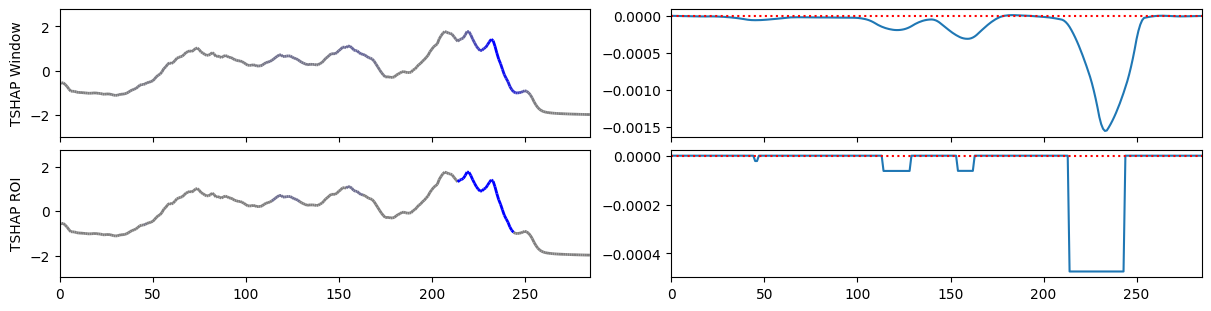

In [12]:
id = 1
sample = X_test[id,0,:]
attribs = [attr[id,0,:] for attr in [tshap_window_attribs, tshap_roi_attribs]]
plot_saliency_map_and_attributions(sample,attribs, ['TSHAP Window', 'TSHAP ROI'])

### Multivariate Time Series

In [13]:
data = np.load('data/CMJ.npy',allow_pickle=True).item()
X_train = data["train"]["X"]
y_train = np.array([int(x) for x in data["train"]["y"]])

X_test = data["test"]["X"]
y_test = np.array([int(x) for x in data["test"]["y"]])

# select 20 random baseline samples from the training set
baseline_indexes = np.random.choice(X_train.shape[0], size=20, replace=False)

clf = make_pipeline(
            MiniRocket(random_state=42),
            StandardScaler(with_mean=False),
            LogisticRegression(max_iter=1000), # replace the default RidgeCV with LogisticRegression to get the prediction probability
        ).fit(X_train,y_train)

In [ ]:
# explain 2 samples in the test set
# for multiclass data the explanation target is needed and usually the predicted class
samples = X_test[100:102]
predicted_classes = clf.predict(samples)
tshap_window_attribs, tshap_roi_attribs = TSHAPExplainer().explain(samples, baselines=X_train[baseline_indexes], model=clf, clf_targets= predicted_classes)

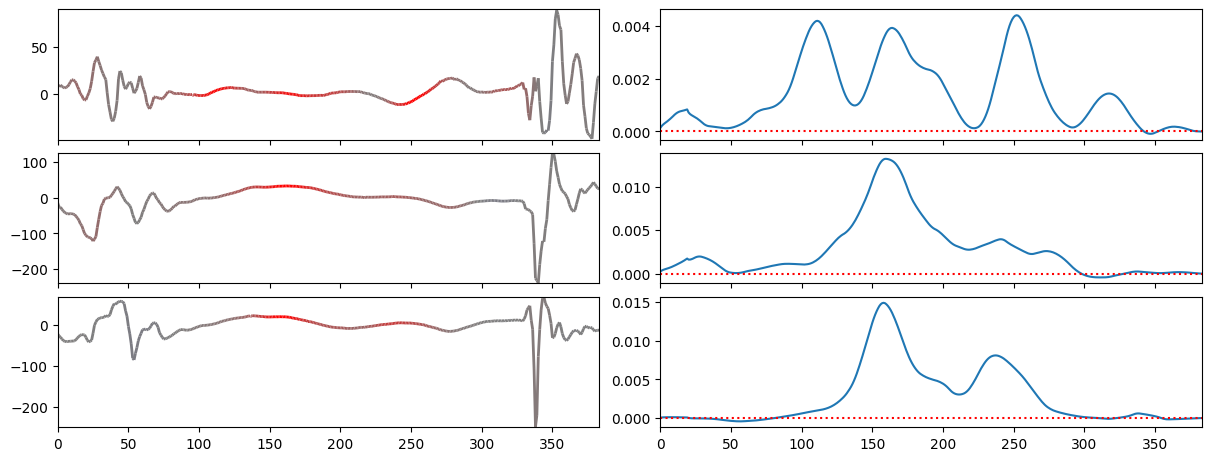

In [32]:
plot_multivariate_sample_attributions(samples[0], tshap_window_attribs[0])

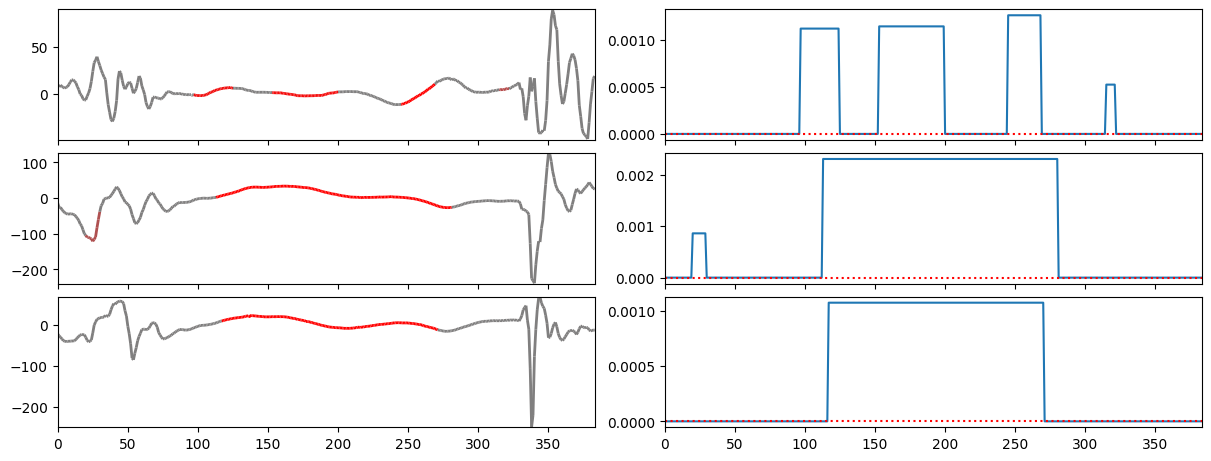

In [33]:
plot_multivariate_sample_attributions(samples[0], tshap_roi_attribs[0])